# Protein-Protein Interaction (PPI) Prediction using Machine Learning


## Imports

In [8]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Conv1D,
    Bidirectional, LSTM, Dense, Dropout,
    Concatenate, GlobalMaxPooling1D, GlobalAveragePooling1D,
    BatchNormalization, Multiply, Subtract
)
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, matthews_corrcoef,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

## Feature Extraction

In [9]:
def extract_aac_features(sequences):
    amino_acids = "ACDEFGHIKLMNPQRSTVWY"
    features = []
    for seq in sequences:
        seq = str(seq).upper()
        length = len(seq) if len(seq) > 0 else 1
        counts = [seq.count(aa) / length for aa in amino_acids]
        features.append(counts)
    return np.array(features)

## Data Loading & Encoding

In [10]:
pos_df = pd.read_csv("/kaggle/input/datasets/spandansureja/ppi-dataset/positive_protein_sequences.csv").iloc[:, :2]
neg_df = pd.read_csv("/kaggle/input/datasets/spandansureja/ppi-dataset/negative_protein_sequences.csv").iloc[:, :2]

pos_df.columns = ["p1", "p2"]
neg_df.columns = ["p1", "p2"]
pos_df["label"] = 1
neg_df["label"] = 0

df = pd.concat([pos_df, neg_df], ignore_index=True).sample(frac=1, random_state=42)

amino_acids = "ACDEFGHIKLMNPQRSTVWY"
aa_to_int = {aa: i + 1 for i, aa in enumerate(amino_acids)}

def encode(seq):
    return [aa_to_int.get(aa, 0) for aa in str(seq).upper()]

MAX_LEN = 500

X1_seq = pad_sequences(df["p1"].apply(encode), maxlen=MAX_LEN, padding="post")
X2_seq = pad_sequences(df["p2"].apply(encode), maxlen=MAX_LEN, padding="post")
X1_aac = extract_aac_features(df["p1"])
X2_aac = extract_aac_features(df["p2"])
y = df["label"].values

(
    X1_s_tr, X1_s_ts, X2_s_tr, X2_s_ts,
    X1_a_tr, X1_a_ts, X2_a_tr, X2_a_ts,
    y_train, y_test
) = train_test_split(
    X1_seq, X2_seq, X1_aac, X2_aac, y,
    test_size=0.2, stratify=y, random_state=42
)

print(f"Training samples : {len(y_train)}")
print(f"Test samples     : {len(y_test)}")

Training samples : 58488
Test samples     : 14622


## Model Architecture
### Building Blocks

In [11]:
def multi_kernel_block(x):
    b3 = Conv1D(64, 3, padding="same", activation="relu")(x)
    b5 = Conv1D(64, 5, padding="same", activation="relu")(x)
    b7 = Conv1D(64, 7, padding="same", activation="relu")(x)
    m = Concatenate()([b3, b5, b7])
    return Concatenate()([GlobalAveragePooling1D()(m), GlobalMaxPooling1D()(m)])


def cross_attention(f1, f2):
    """Soft-attention: each residue in f1 attends over all residues in f2."""
    score    = tf.keras.layers.Dot(axes=[2, 2])([f1, f2])
    weights  = tf.keras.layers.Softmax(axis=-1)(score)
    attended = tf.keras.layers.Dot(axes=[2, 1])([weights, f2])
    return GlobalAveragePooling1D()(attended)


def collaborative_fusion(b1, b2):
    """Gated fusion: learns which interaction signals matter most."""
    concat   = Concatenate()([b1, b2])
    mul      = Multiply()([b1, b2])
    diff     = Subtract()([b1, b2])
    combined = Concatenate()([concat, mul, diff])
    gate     = Dense(combined.shape[-1], activation="sigmoid")(combined)
    fusion   = gate * combined
    fusion   = Dense(256, activation="relu")(fusion)
    fusion   = BatchNormalization()(fusion)
    return fusion

### Full Model Definition

In [12]:
# ── Shared Layers ────────────────────────────────────────
emb  = Embedding(input_dim=21, output_dim=128)
lstm = Bidirectional(LSTM(64, return_sequences=True))

def protein_branch(seq_in, aac_in):
    x = emb(seq_in)
    x = lstm(x)
    residue_features = x
    pooled = multi_kernel_block(x)
    fused  = Concatenate()([pooled, aac_in])
    fused  = Dense(128, activation="relu")(fused)
    fused  = BatchNormalization()(fused)
    return fused, residue_features

# ── Inputs ───────────────────────────────────────────────
in1_seq = Input(shape=(MAX_LEN,))
in2_seq = Input(shape=(MAX_LEN,))
in1_aac = Input(shape=(20,))
in2_aac = Input(shape=(20,))

# ── Branch Outputs ───────────────────────────────────────
(b1, f1) = protein_branch(in1_seq, in1_aac)
(b2, f2) = protein_branch(in2_seq, in2_aac)

# ── Cross-Attention Features ─────────────────────────────
attn_1        = cross_attention(f1, f2)
attn_2        = cross_attention(f2, f1)
attn_features = Concatenate()([attn_1, attn_2])

# ── Collaborative Fusion ─────────────────────────────────
fusion_core = collaborative_fusion(b1, b2)
merged      = Concatenate()([fusion_core, attn_features])

# ── Classification Head ──────────────────────────────────
dense = Dense(256, activation="relu")(merged)
dense = Dropout(0.5)(dense)
dense = Dense(128, activation="relu")(dense)
out   = Dense(1, activation="sigmoid")(dense)

model = Model(inputs=[in1_seq, in2_seq, in1_aac, in2_aac], outputs=out)

# Feature extractor — exposes residue-level outputs alongside prediction
feature_extractor = Model(
    inputs=model.inputs,
    outputs=[f1, f2, out]
)

model.summary()

I0000 00:00:1777587210.424037      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 500)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 500)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 500, 128)  │      2,688 │ input_layer[0][0… │
│ (Embedding)         │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 500, 128)  │     98,816 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ embedding[1][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 500, 64)   │     24,640 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 500, 64)   │     41,024 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 500, 64)   │     57,408 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 500, 64)   │     24,640 │ bidirectional[1]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 500, 64)   │     41,024 │ bidirectional[1]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 500, 64)   │     57,408 │ bidirectional[1]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 500, 192)  │          0 │ conv1d[0][0],     │
│ (Concatenate)       │                   │            │ conv1d_1[0][0],   │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 500, 192)  │          0 │ conv1d_3[0][0],   │
│ (Concatenate)       │                   │            │ conv1d_4[0][0],   │
│                     │                   │            │ conv1d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 192)       │          0 │ concatenate[0][0] │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 192)       │          0 │ concatenate[0][0] │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 192)       │          0 │ concatenate_3[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 192)       │          0 │ concatenate_3[0]… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 384)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                 

 Total params: 1,011,713 (3.86 MB)

 Trainable params: 1,010,689 (3.86 MB)

 Non-trainable params: 1,024 (4.00 KB)

### Compile Model

In [13]:
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
]

## Training

In [14]:
history = model.fit(
    [X1_s_tr, X2_s_tr, X1_a_tr, X2_a_tr],
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20


I0000 00:00:1777587221.208029     106 cuda_dnn.cc:529] Loaded cuDNN version 91002


732/732 ━━━━━━━━━━━━━━━━━━━━ 121s 149ms/step - accuracy: 0.7169 - loss: 0.5353 - val_accuracy: 0.9409 - val_loss: 0.1791 - learning_rate: 1.0000e-04
Epoch 2/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 108s 147ms/step - accuracy: 0.9563 - loss: 0.1306 - val_accuracy: 0.9133 - val_loss: 0.2725 - learning_rate: 1.0000e-04
Epoch 3/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 108s 148ms/step - accuracy: 0.9774 - loss: 0.0780 - val_accuracy: 0.9661 - val_loss: 0.1091 - learning_rate: 1.0000e-04
Epoch 4/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 108s 147ms/step - accuracy: 0.9821 - loss: 0.0596 - val_accuracy: 0.9767 - val_loss: 0.0844 - learning_rate: 1.0000e-04
Epoch 5/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 108s 147ms/step - accuracy: 0.9846 - loss: 0.0521 - val_accuracy: 0.9774 - val_loss: 0.0817 - learning_rate: 1.0000e-04
Epoch 6/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 108s 147ms/step - accuracy: 0.9850 - loss: 0.0516 - val_accuracy: 0.9643 - val_loss: 0.1370 - learning_rate: 1.0000e-04
Epoch 7/20
732/732 ━━━━━━━━━━━━━━━━━━━━ 108s 147ms/

## Training Curves

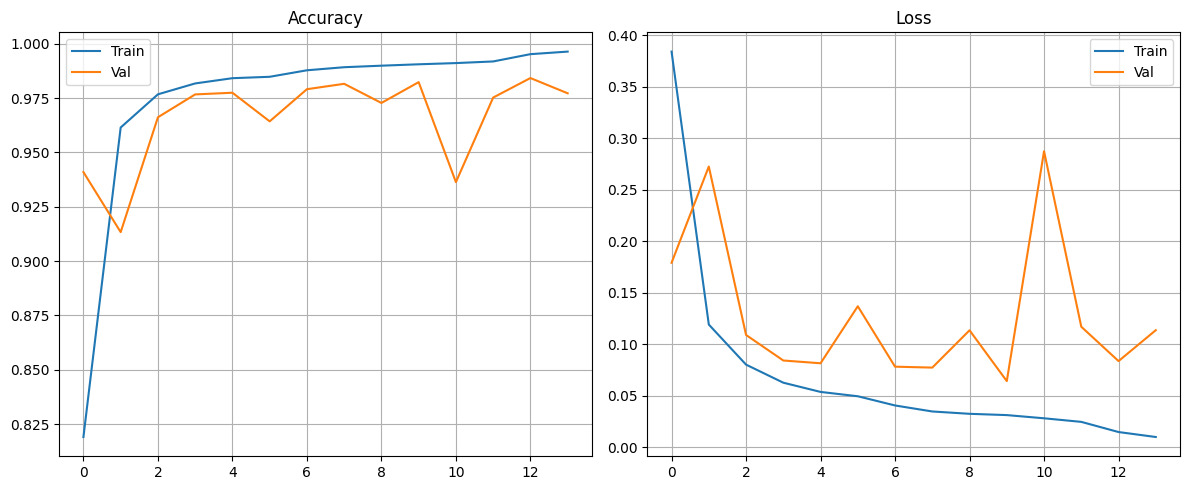

In [15]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend(); plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend(); plt.grid()

plt.tight_layout()
plt.show()

## Predictions

In [16]:
y_prob = model.predict([X1_s_ts, X2_s_ts, X1_a_ts, X2_a_ts])
y_pred = (y_prob > 0.5).astype(int)

457/457 ━━━━━━━━━━━━━━━━━━━━ 21s 44ms/step


## Confusion Matrix

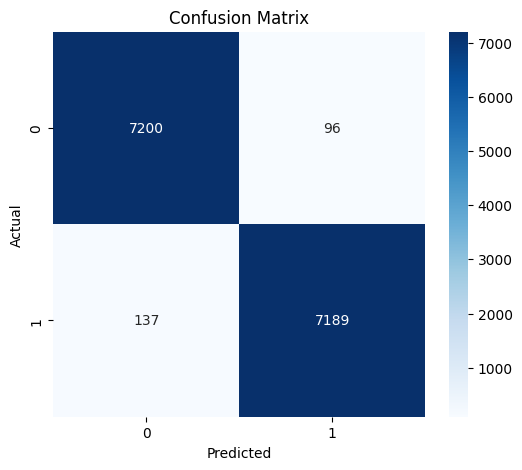

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Metrics Table

In [18]:
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
auc       = roc_auc_score(y_test, y_prob)
auprc     = average_precision_score(y_test, y_prob)
mcc       = matthews_corrcoef(y_test, y_pred)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "AUC", "AUPRC", "MCC"],
    "Value":  [accuracy, precision, recall, f1, auc, auprc, mcc]
})

print("\n Model Performance Summary:\n")
print(metrics_df.to_string(index=False))


 Model Performance Summary:

   Metric    Value
 Accuracy 0.984065
Precision 0.986822
   Recall 0.981299
 F1 Score 0.984053
      AUC 0.994852
    AUPRC 0.992895
      MCC 0.968146


## Residue-Level Contact Map

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 674ms/step


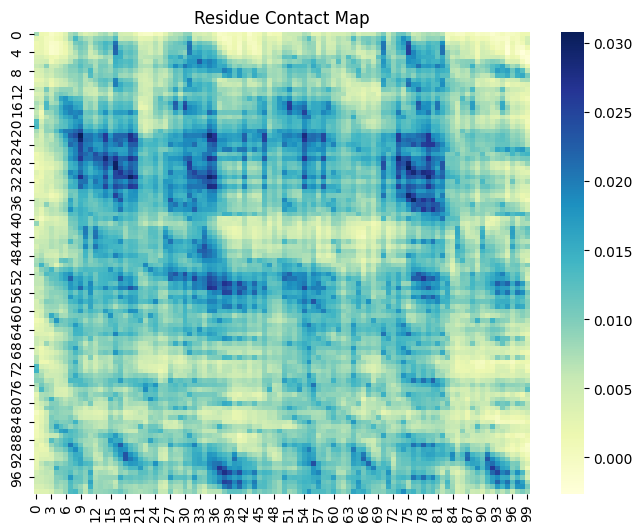

In [19]:
idx = np.where((y_test == 1) & (y_prob.flatten() > 0.8))[0][0]

feat1, feat2, prob = feature_extractor.predict(
    [X1_s_ts[idx:idx+1], X2_s_ts[idx:idx+1],
     X1_a_ts[idx:idx+1], X2_a_ts[idx:idx+1]]
)

N_RES = 100
contact_map = np.matmul(feat1[0, :N_RES, :], feat2[0, :N_RES, :].T)

plt.figure(figsize=(8, 6))
sns.heatmap(contact_map, cmap="YlGnBu")
plt.title("Residue Contact Map")
plt.show()

## Binding Interface Map

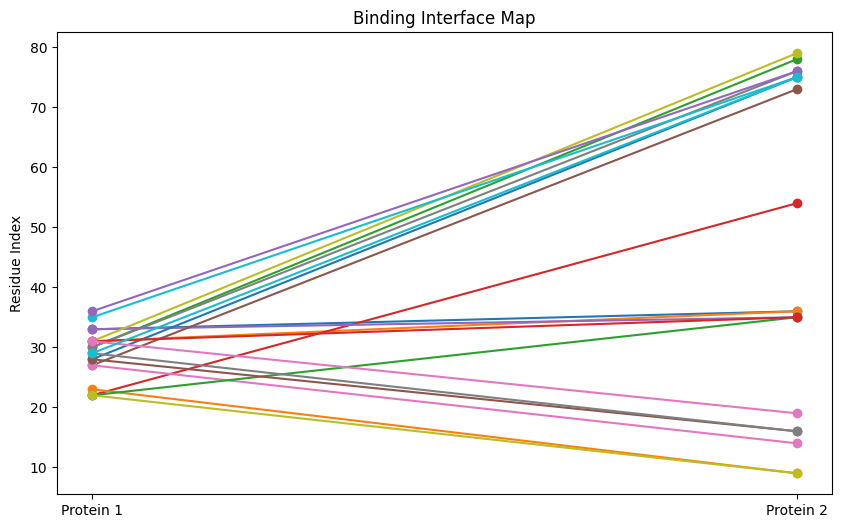

In [20]:
plt.figure(figsize=(10, 6))

top_k = 20
flat_idx = np.argsort(contact_map.flatten())[-top_k:]
rows, cols = np.unravel_index(flat_idx, contact_map.shape)

for r, c in zip(rows, cols):
    plt.plot([0, 1], [r, c], marker='o')

plt.title("Binding Interface Map")
plt.xticks([0, 1], ["Protein 1", "Protein 2"])
plt.ylabel("Residue Index")
plt.show()

## Energy Distribution Plot

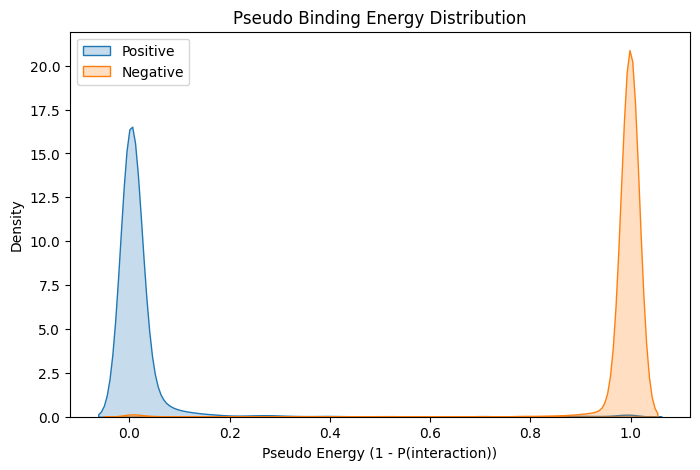

In [21]:
energies = 1 - y_prob.flatten()

plt.figure(figsize=(8, 5))
sns.kdeplot(energies[y_test == 1], fill=True, label='Positive')
sns.kdeplot(energies[y_test == 0], fill=True, label='Negative')
plt.title("Pseudo Binding Energy Distribution")
plt.xlabel("Pseudo Energy (1 - P(interaction))")
plt.legend()
plt.show()

## In-Silico Mutation

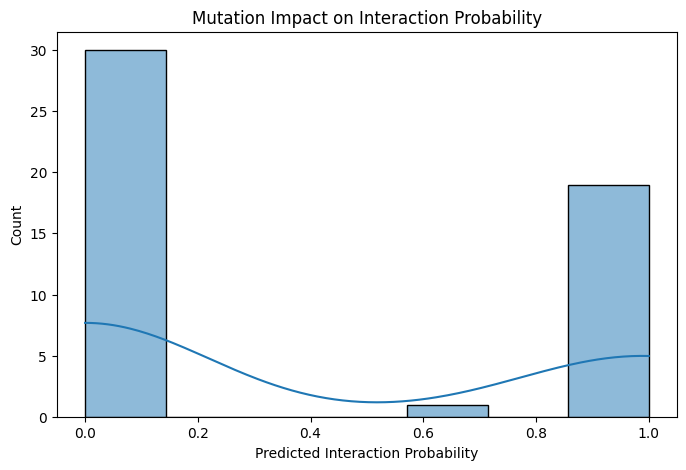

In [22]:
def mutate_sequence(seq):
    seq = seq.copy()
    pos = np.random.randint(0, len(seq))
    seq[pos] = np.random.randint(1, 21)
    return seq

mut_preds = []

for i in range(50):
    m1 = mutate_sequence(X1_s_ts[i])
    m2 = mutate_sequence(X2_s_ts[i])

    pred = model.predict([
        m1.reshape(1, -1),
        m2.reshape(1, -1),
        X1_a_ts[i].reshape(1, -1),
        X2_a_ts[i].reshape(1, -1)
    ], verbose=0)
    mut_preds.append(pred[0][0])

plt.figure(figsize=(8, 5))
sns.histplot(mut_preds, kde=True)
plt.title("Mutation Impact on Interaction Probability")
plt.xlabel("Predicted Interaction Probability")
plt.show()

## Alanine Scanning
Identifies binding **hot-spot residues** via confidence-drop analysis.

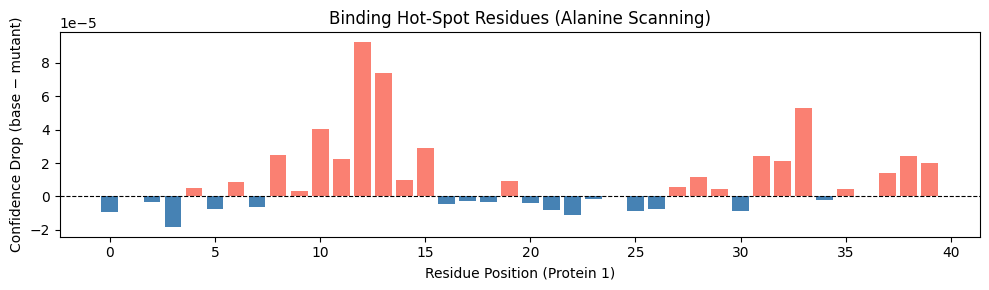

  Base confidence : 0.9999
  Max drop at pos : 12  (0.0001)


In [23]:
def perform_alanine_scan(p1_str, p2_str):
    """Identify 'Hot Spot' residues via confidence-drop analysis."""

    def get_pred(s1, s2):
        return model.predict(
            [
                pad_sequences([encode(s1)], maxlen=MAX_LEN, padding='post'),
                pad_sequences([encode(s2)], maxlen=MAX_LEN, padding='post'),
                extract_aac_features([s1]),
                extract_aac_features([s2]),
            ],
            verbose=0
        )[0][0]

    base_val   = get_pred(p1_str, p2_str)
    importance = []
    p1_list    = list(p1_str)

    for i in range(min(40, len(p1_list))):
        mutated    = p1_list.copy()
        mutated[i] = 'A'
        importance.append(base_val - get_pred("".join(mutated), p2_str))

    plt.figure(figsize=(10, 3))
    colors = ['salmon' if v > 0 else 'steelblue' for v in importance]
    plt.bar(range(len(importance)), importance, color=colors)
    plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    plt.title("Binding Hot-Spot Residues (Alanine Scanning)")
    plt.xlabel("Residue Position (Protein 1)")
    plt.ylabel("Confidence Drop (base − mutant)")
    plt.tight_layout()
    plt.savefig('alanine_scan.png', dpi=150)
    plt.show()
    print(f"  Base confidence : {base_val:.4f}")
    print(f"  Max drop at pos : {int(np.argmax(importance))}  ({max(importance):.4f})")

# Run on the first sample in the dataset
perform_alanine_scan(df.iloc[0]['p1'], df.iloc[0]['p2'])

## Network Reconstruction
Reconstructs a mini **interactome** from a subset of unique proteins.


Reconstructing Predicted Interaction Network...
  Nodes: 8  |  Edges: 21


/tmp/ipykernel_57/825661310.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


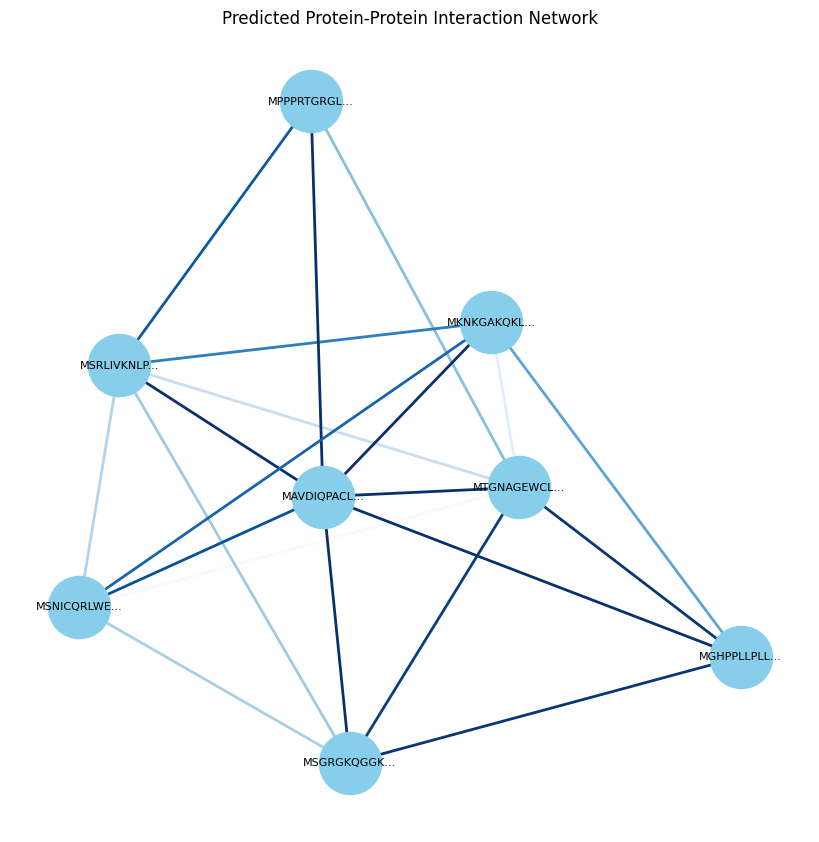

In [24]:
def visualize_predicted_network(num_proteins=8):
    """Reconstruct a mini-interactome from a subset of unique proteins."""

    unique_prots = list(set(df['p1'].tolist()))[:num_proteins]

    G = nx.Graph()
    labels = {p: p[:10] + "..." for p in unique_prots}
    for p in unique_prots:
        G.add_node(labels[p])

    print("\nReconstructing Predicted Interaction Network...")
    for i in range(len(unique_prots)):
        for j in range(i + 1, len(unique_prots)):
            s1, s2 = unique_prots[i], unique_prots[j]

            score = model.predict(
                [
                    pad_sequences([encode(s1)], maxlen=MAX_LEN, padding='post'),
                    pad_sequences([encode(s2)], maxlen=MAX_LEN, padding='post'),
                    extract_aac_features([s1]),
                    extract_aac_features([s2]),
                ],
                verbose=0
            )[0][0]

            if score > 0.85:
                G.add_edge(labels[s1], labels[s2], weight=float(score))

    print(f"  Nodes: {G.number_of_nodes()}  |  Edges: {G.number_of_edges()}")

    plt.figure(figsize=(8, 8))
    pos         = nx.spring_layout(G, k=0.5, seed=42)
    edge_weights = [G[u][v]['weight'] for u, v in G.edges()]
    nx.draw(
        G, pos,
        with_labels  = True,
        node_color   = 'skyblue',
        node_size    = 2000,
        font_size    = 8,
        edge_color   = edge_weights,
        edge_cmap    = plt.cm.Blues,
        width        = 2,
    )
    plt.title("Predicted Protein-Protein Interaction Network")
    plt.tight_layout()
    plt.savefig('predicted_network.png', dpi=150)
    plt.show()

visualize_predicted_network(num_proteins=8)